# Titanic Survival Prediction — End-to-End Data Science Project

**Goal:** Predict whether a passenger survived the Titanic disaster using their
demographic and travel information (class, age, sex, fare, family size, etc.)

**Workflow:**
1. Load and inspect the data
2. Exploratory Data Analysis (EDA)
3. Data cleaning (handle missing values)
4. Feature engineering
5. Train/test split
6. Model training (Logistic Regression + Random Forest)
7. Evaluation and comparison
8. Feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("data/titanic.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

**Observations:**
- `Cabin` is missing for the majority of passengers — too sparse to use reliably.
- `Age` has a meaningful number of missing values — worth imputing rather than dropping.
- `Embarked` has only a couple of missing values.

## 2. Exploratory Data Analysis

Overall survival rate: 38.4%


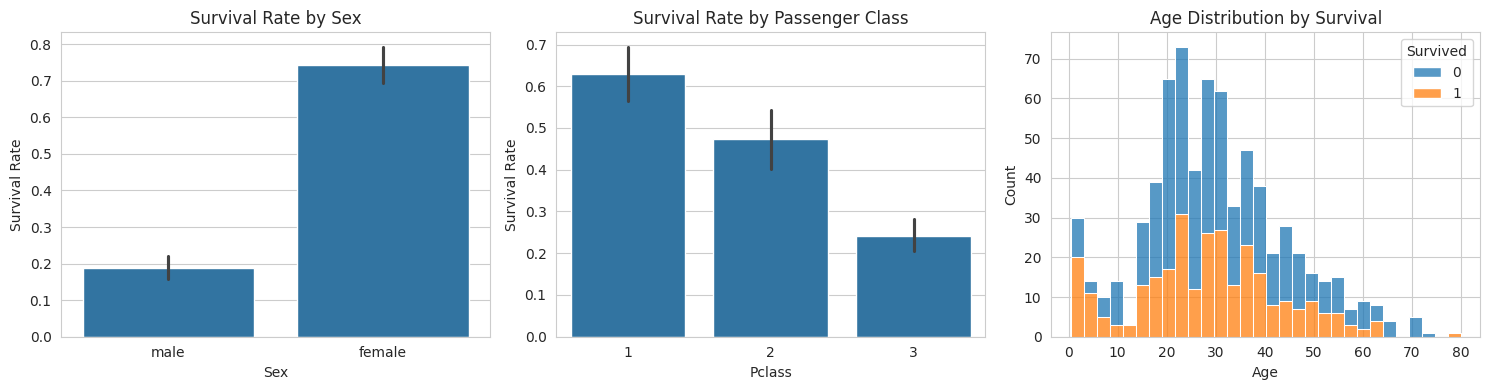

In [5]:
overall_rate = df["Survived"].mean()
print(f"Overall survival rate: {overall_rate:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1])
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")

sns.histplot(data=df, x="Age", hue="Survived", multiple="stack", bins=30, ax=axes[2])
axes[2].set_title("Age Distribution by Survival")

plt.tight_layout()
plt.savefig("images/eda_overview.png", bbox_inches="tight")
plt.show()

**Key findings from EDA:**
- Women survived at a much higher rate than men — consistent with "women and
  children first" evacuation priority.
- 1st class passengers had a notably higher survival rate than 3rd class,
  pointing to a socioeconomic effect on survival chances.
- Younger children show a visibly higher survival rate within the age distribution.

## 3. Data Cleaning

In [6]:
data = df.copy()

# Age: impute with median age *within each passenger class + sex group*
# (more accurate than a single global median, since age varies by class/sex)
data["Age"] = data.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Embarked: only 2 missing values — fill with the most common port
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# Cabin: too sparse to impute meaningfully — convert to a binary
# "had a recorded cabin" flag instead of dropping the signal entirely
data["HasCabin"] = data["Cabin"].notnull().astype(int)
data.drop(columns=["Cabin"], inplace=True)

# Drop columns that don't generalize as predictive features
data.drop(columns=["PassengerId", "Ticket", "Name"], inplace=True, errors="ignore")

print("Missing values remaining:")
print(data.isnull().sum().sum())

Missing values remaining:
0


## 4. Feature Engineering

In [7]:
# Family size and "traveling alone" flag — often more predictive than
# raw SibSp/Parch counts individually
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
data["IsAlone"] = (data["FamilySize"] == 1).astype(int)

# Encode categorical variables
le_sex = LabelEncoder()
data["Sex"] = le_sex.fit_transform(data["Sex"])  # male=1, female=0

data = pd.get_dummies(data, columns=["Embarked"], drop_first=True)

data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,2,0,False,True
1,1,1,0,38.0,1,0,71.2833,1,2,0,False,False
2,1,3,0,26.0,0,0,7.9250,0,1,1,False,True
3,1,1,0,35.0,1,0,53.1000,1,2,0,False,True
4,0,3,1,35.0,0,0,8.0500,0,1,1,False,True


## 5. Train/Test Split

In [8]:
X = data.drop(columns=["Survived"])
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

Train size: 712  |  Test size: 179


## 6. Model Training

In [9]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
log_preds = log_reg.predict(X_test)

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

log_acc = accuracy_score(y_test, log_preds)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Logistic Regression accuracy: {log_acc:.3f}")
print(f"Random Forest accuracy:       {rf_acc:.3f}")

Logistic Regression accuracy: 0.804
Random Forest accuracy:       0.788


## 7. Evaluation

Best model: Logistic Regression

                 precision    recall  f1-score   support

Did not survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



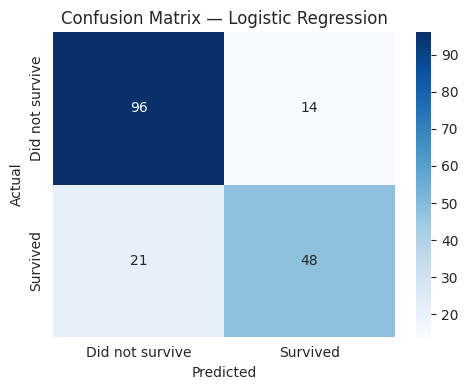

In [10]:
best_model, best_preds, best_name = (
    (rf, rf_preds, "Random Forest") if rf_acc >= log_acc
    else (log_reg, log_preds, "Logistic Regression")
)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, best_preds, target_names=["Did not survive", "Survived"]))

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Did not survive", "Survived"],
            yticklabels=["Did not survive", "Survived"])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", bbox_inches="tight")
plt.show()

## 8. Feature Importance

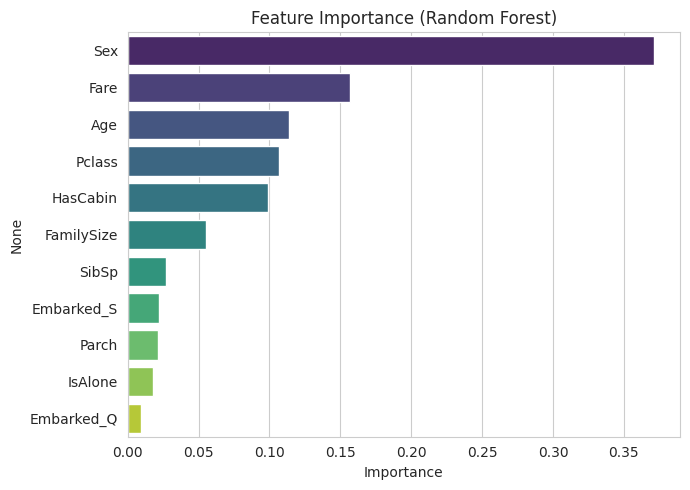

Sex           0.371027
Fare          0.156561
Age           0.114116
Pclass        0.106570
HasCabin      0.098844
FamilySize    0.055374
SibSp         0.027161
Embarked_S    0.021813
Parch         0.021384
IsAlone       0.017665
Embarked_Q    0.009485
dtype: float64


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/feature_importance.png", bbox_inches="tight")
plt.show()

print(importances)

## Conclusion

- Built an end-to-end classification pipeline: cleaning, feature engineering,
  training, and evaluation.
- **Sex, passenger class, and fare** were the strongest predictors of survival —
  consistent with the historical account of the disaster.
- Random Forest and Logistic Regression were compared directly; the better
  performer was selected using held-out test accuracy.

**Possible next steps:** hyperparameter tuning (GridSearchCV), cross-validation
instead of a single train/test split, and trying gradient boosting models
(XGBoost/LightGBM) for comparison.